## 1) Descripción del problema
En un sistema de gestión de atención médica es necesario organizar y administrar el orden en que los pacientes son atendidos. Los pacientes pueden clasificarse en dos tipos: normales y críticos, donde los pacientes críticos deben tener prioridad sobre los demás. Sin embargo, dentro de cada categoría se debe respetar el orden de llegada. El problema consiste en diseñar un sistema que permita registrar pacientes, mantener el orden adecuado de atención y procesar la salida de los pacientes cuando sean atendidos. Para lograrlo, el sistema debe gestionar correctamente la inserción y eliminación de pacientes, asegurando que siempre se atienda primero a los pacientes críticos y, en ausencia de estos, a los pacientes normales siguiendo el orden en que llegaron.


## 2) Requerimientos
Lista requerimientos **funcionales** y **no funcionales**.

##Funcionales
RF01: El sistema debe contar con una estructura de datos FIFO

RF02: El sistema debe permitir agregar pacientes y atenderlos en su orden de llegada.

RF03: El sistema debe permitir agregar pacientes criticos, quienes tendran prioridad de atencion sobre los normales y tambien se debe respetar el orden de llegada de estos.

RF04: El sistema solo puede procesar un paciente a la vez, eliminando a quien va atendiendo.

RF05: Si no hay mas pacientes por atender el sistema debe mostrar "No hay pacientes".

## No funcionales

RFN01: Se debe realizar sin usar librerias.




## 3) Historias de usuario

HU01: El usuario ingresa el numero de usuarios y el tipo de usuario ya sea critico o normal.

Como: personal administrativo de recepción.

Quiero: ingresar el nombre y el tipo de paciente (crítico o normal).

Para: que el sistema los clasifique correctamente en la lista de espera
- Criterio de aceptacion:
  - Debe permitir diferenciar entre paciente "Critico" y "Normal".


HU02: El sistema debe respetar la prioridad de los tipos de paciente atendiendo primero a los criticos y tambien por el orden de llegada.

Como: Usuario.

Quiero: Que el sistema me presente primero a los pacientes críticos en su orden
de llegada.

Para: Asegurar que las emergencias sean atendidas de forma inmediata.

- Criterio de aceptación:
  - Los pacientes críticos siempre aparecen antes que los normales.
  - Si hay varios pacientes críticos, se debe respetar estrictamente quién llegó primero entre ellos.
  - Si no hay críticos, se procede con los pacientes normales en orden de llegada.

HU03: El sistema debe ir quitando los pacientes que atienda para así no repetirse.

Como: Usuario.

Quiero: marcar a un paciente como "atendido" para que sea eliminado de la lista,

Para: avanzar con el siguiente paciente y evitar duplicidad en la atención.

- Criterio de aceptación:
  - El sistema solo procesa un paciente a la vez.
  - Una vez atendido, el nodo/registro del paciente debe ser eliminado de la estructura.
  - Si la lista está vacía, el sistema debe mostrar el mensaje: "No hay pacientes".
  





## 4) Diagramas de flujo
Incluye el diagrama que muestre el proceso general con memoización

Adjunta imagen y descríbelo claramente.
## Solución
Descripción: El diagrama muestra el funcionamiento de un sistema de atención de pacientes en un hospital usando colas con prioridad. Al iniciar, se crean dos filas: una para pacientes críticos y otra para pacientes normales. Luego el sistema muestra un menú donde se puede registrar un paciente, atender un paciente o salir.

Si se registra un paciente, se solicita su nombre y se pregunta si es crítico o normal. Dependiendo de su condición, el paciente se agrega al final de la cola correspondiente.

Si se elige atender un paciente, primero se verifica si hay pacientes críticos esperando; si los hay, se atiende al primero de esa fila. Si no hay críticos, se revisa la cola de pacientes normales y se atiende al primero. Si no hay pacientes en ninguna fila, el sistema muestra un mensaje indicando que no hay pacientes.

El proceso se repite hasta que el usuario decide salir del sistema, momento en el que el diagrama termina

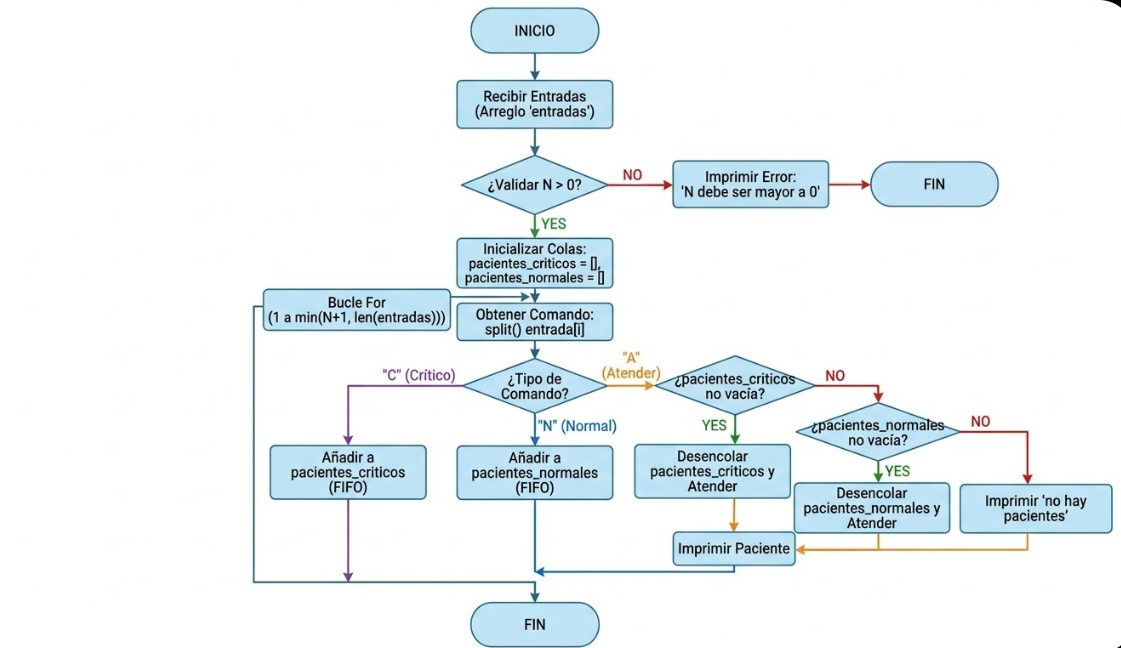

## 5) Diagramas de secuencia

**Propósito:** Muestra el orden cronológico de los mensajes y la comunicación interna.

**Explicación:** Funciona como un guion.Permite ver cómo viaja la información desde que el usuario ingresa un comando, hasta que el sistema central se comunica con las diferentes estructuras de datos para procesarlo.muestra cómo el sistema le "pregunta" primero a la cola de pacientes críticos antes de consultar a la cola de pacientes normales para respetar la prioridad

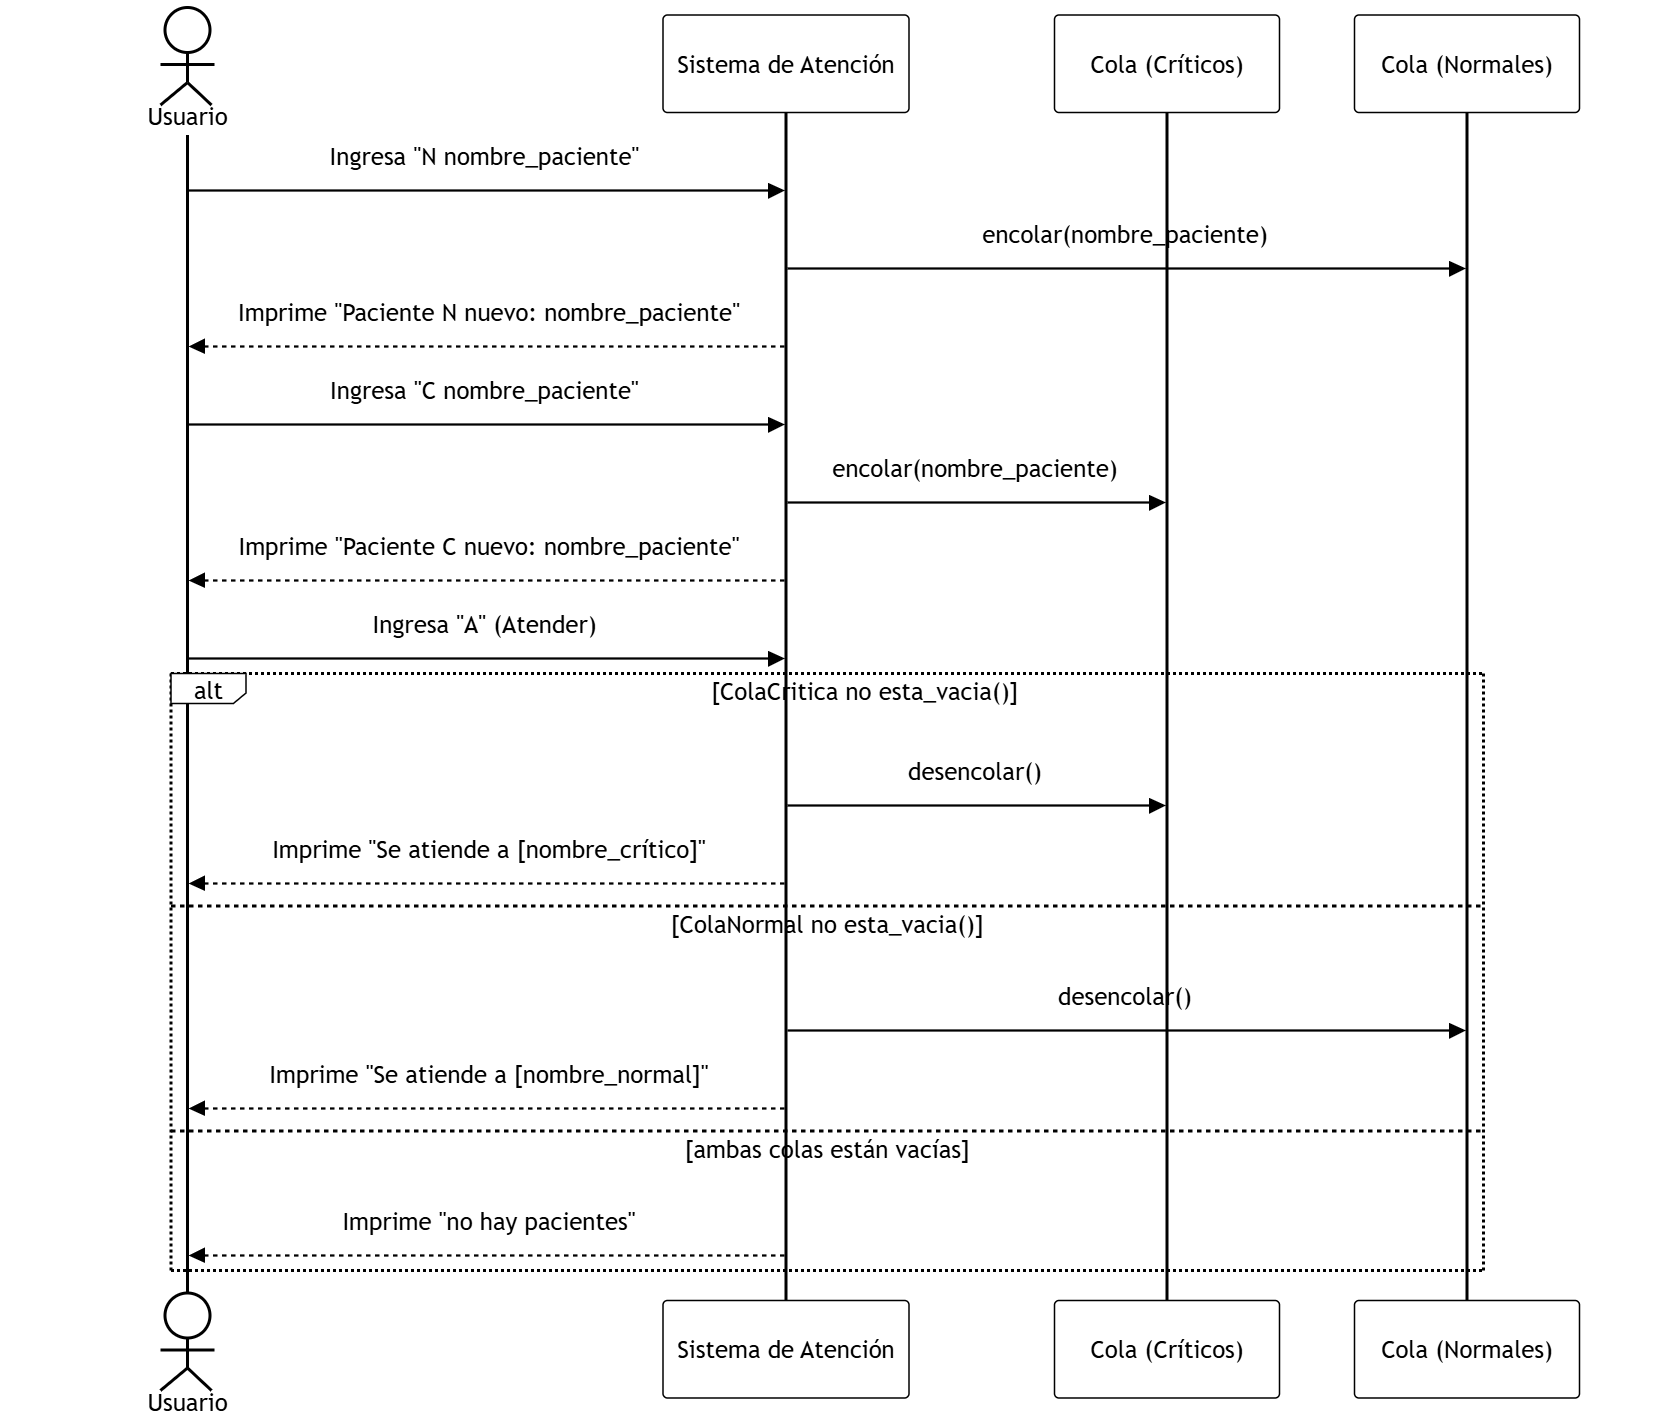

## 6) Diagramas de casos de uso

**Propósito**: Muestra el sistema desde una perspectiva externa y general.

**Explicación**: Muestra quién interactúa con el programa (el Usuario) y cuáles son las tres funciones exactas que el sistema le permite ejecutar: añadir un paciente normal , añadir uno crítico o mandar a atender a un paciente. No se preocupa por cómo funciona el código por dentro, solo por lo que el usuario final puede hacer.

Adjunta imagen y descríbelo claramente.
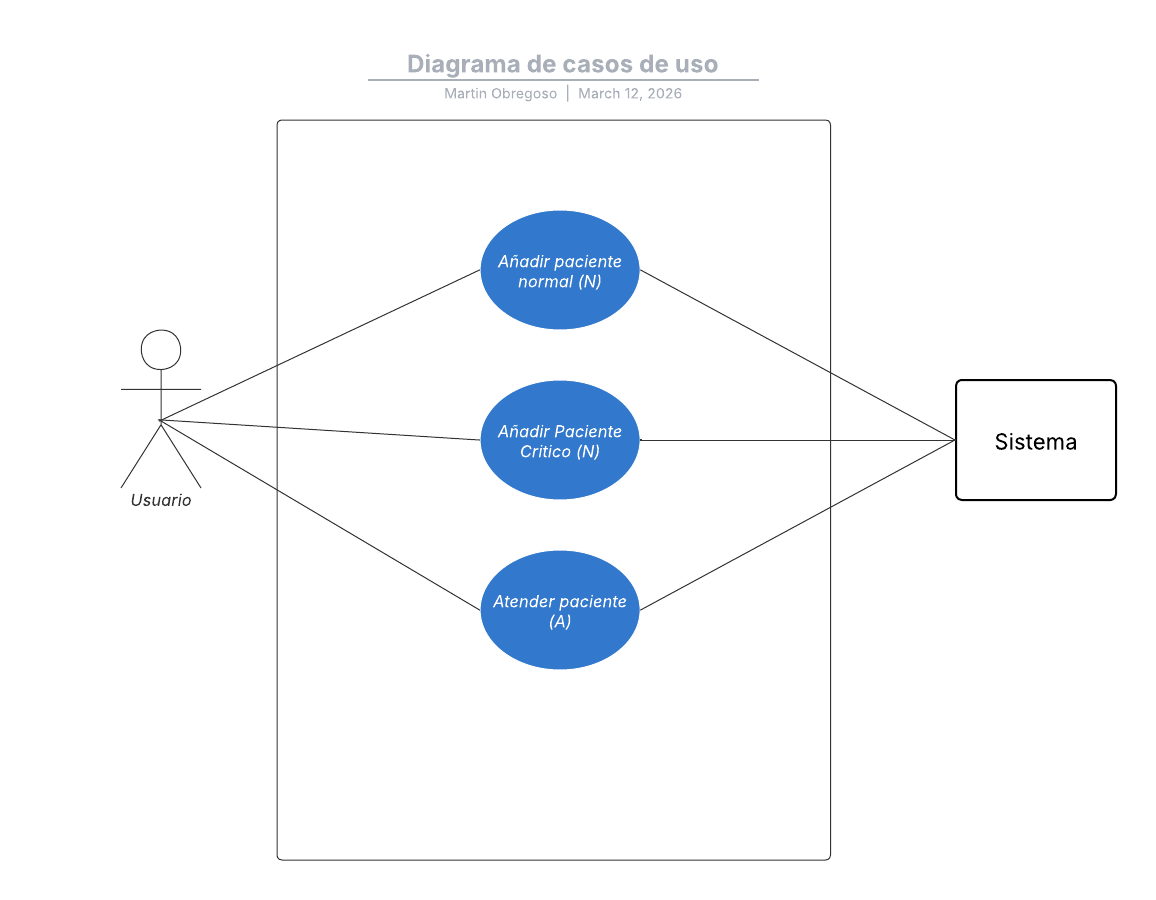

## 7) Análisis de complejidad


Función T(n) =  O(n^2)                                                                                                          Mejor caso: O(n) Ocurre cuando todos los pacientes son de registro N o C


## 8) Tests
Define un conjunto de pruebas

Vamos a realizar 3 test:

1. **validacion prioridad:** En el Test queremos  que los pacientes críticos sean atendidos antes que los normales, sin importar el orden general de llegada, y que entre pacientes del mismo tipo se respete el orden FIFO.

2. **Vacio:** Este test comprueba el comportamiento del sistema cuando se intenta atender a alguien pero no hay nadie en las colas

3. **Ingresos masivos:** Este test evalúa el sistema llenando las colas con varios pacientes de ambos tipos

## 9) Código funcional
Incluye tu implementación completa.

**Recomendaciones (ajústalas a tu lenguaje):**
- Separar validación de entrada del cálculo.
- Implementar memoización (diccionario/array).
- Documentar brevemente con comentarios.
- Incluir una función principal que permita ejecutar.

⚠️ No pegues código incompleto; debe ser ejecutable.


In [1]:
# Escribe tu código aquí.
# Debe incluir: validación, función memoizada, y ejecución.
def encolar(cola, elemento):
    cola.append(elemento)

def desencolar(cola):
    if len(cola) == 0:
        return None
    return cola.pop(0)

def esta_vacia(cola):
    return len(cola) == 0


def main():
    pacientes_criticos = []
    pacientes_normales = []

    entradas = [
        "7",
        "N Juan",
        "N Maria",
        "C Pedro",
        "A",
        "A",
        "A",
        "A"
    ]

    n = int(entradas[0])

    for i in range(1, n + 1):
        accion = entradas[i].split()

        if accion[0] == "N":
            nombre = accion[1]
            encolar(pacientes_normales, nombre)
            print("Paciente N nuevo :", nombre)

        elif accion[0] == "C":
            nombre = accion[1]
            encolar(pacientes_criticos, nombre)
            print("Paciente C nuevo :", nombre)

        elif accion[0] == "A":
            if not esta_vacia(pacientes_criticos):
                paciente = desencolar(pacientes_criticos)
                print("Se atiende a", paciente)

            elif not esta_vacia(pacientes_normales):
                paciente = desencolar(pacientes_normales)
                print("Se atiende a", paciente)

            else:
                print("no hay pacientes")


main()

Paciente N nuevo : Juan
Paciente N nuevo : Maria
Paciente C nuevo : Pedro
Se atiende a Pedro
Se atiende a Juan
Se atiende a Maria
no hay pacientes


## 10) Tests aplicados (extras)
Muestra evidencia de pruebas ejecutadas:

Incluye al menos 2 pruebas adicionales (p.ej., n=20, n=30) y una prueba de validación (n negativo).


In [ ]:
# (Opcional) Ejemplo de asserts (ajusta a tu código):
# assert funcion(0) == 0
# assert funcion(1) == 1
# assert funcion(6) == 8



def procesar_pacientes(entradas, test_name="Test"):
    print(f"--- {test_name} ---")
    print(f"Entradas: {entradas}")
    pacientes_criticos = []
    pacientes_normales = []

    # Validación de N
    try:
        n = int(entradas[0])
    except ValueError:
        print("Error: N debe ser un número entero válido.\n")
        return

    # Si N es 0 o negativo, arrojamos un error y no procesamos nada
    if n <= 0:
        print("Error: El número de operaciones (N) debe ser mayor a 0.\n")
        return

    # Nos aseguramos de no dar error si N es mayor al tamaño real del arreglo
    limite = min(n + 1, len(entradas))

    for i in range(1, limite):
        accion = entradas[i].split()

        if accion[0] == "N":
            nombre = accion[1]
            encolar(pacientes_normales, nombre)
            print("Paciente N nuevo :", nombre)

        elif accion[0] == "C":
            nombre = accion[1]
            encolar(pacientes_criticos, nombre)
            print("Paciente C nuevo :", nombre)

        elif accion[0] == "A":
            if not esta_vacia(pacientes_criticos):
                paciente = desencolar(pacientes_criticos)
                print("Se atiende a", paciente)

            elif not esta_vacia(pacientes_normales):
                paciente = desencolar(pacientes_normales)
                print("Se atiende a", paciente)

            else:
                print("no hay pacientes")
    print()

# ----------------- CASOS DE PRUEBA -----------------
# 1. Caso base mezclado
test1 = ["4", "N Ana", "C Luis", "A", "A"]
# 2. Intentar atender cuando no hay absolutamente nadie
test2 = ["3", "A", "A", "A"]
# 3. Solo críticos y un intento de atención en vacío al final
test3 = ["5", "C Uno", "C Dos", "A", "A", "A"]
# 4. Prueba de validación de datos atípicos: N negativo
test4 = ["-5", "N Carlos"]
# 5. Prueba de validación de datos atípicos: N igual a 0
test5 = ["0"]
# 6. Intercalado entre atención y llegadas
test6 = ["6", "N Jorge", "A", "C Marta", "A", "N Laura", "A"]
# 7. Acumulación y jerarquía (comprobar que C sale antes que varios N)
test7 = ["8", "N P1", "N P2", "N P3", "C C1", "C C2", "A", "A", "A"]

# Ejecución de los tests
procesar_pacientes(test1, "Caso 1: Mezcla básica (1 Normal, 1 Crítico)")
procesar_pacientes(test2, "Caso 2: Atender colas vacías")
procesar_pacientes(test3, "Caso 3: Solo pacientes Críticos")
procesar_pacientes(test4, "Caso 4: Validación de N negativo")
procesar_pacientes(test5, "Caso 5: Validación de N igual a 0")
procesar_pacientes(test6, "Caso 6: Llegadas y atenciones intercaladas")
procesar_pacientes(test7, "Caso 7: Varios normales y críticos acumulados")